1. Import Library

In [403]:
import pandas as pd
import numpy as np
import time
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split, cross_validate, KFold, learning_curve, cross_val_predict, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    root_mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

2. Inspeksi Awal

In [404]:
df = pd.read_csv("../data/clean_df.csv")

In [405]:
df.shape

(32536, 12)

In [406]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32536 entries, 0 to 32535
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    32536 non-null  int64  
 1   Price         32536 non-null  float64
 2   Location      32536 non-null  object 
 3   Bedroom       32536 non-null  int64  
 4   Bathroom      32536 non-null  int64  
 5   Carport       32536 non-null  int64  
 6   Land          32536 non-null  int64  
 7   Building      32536 non-null  int64  
 8   Month         32536 non-null  int64  
 9   City/Regency  32536 non-null  object 
 10  Latitude      32536 non-null  float64
 11  Longitude     32536 non-null  float64
dtypes: float64(3), int64(7), object(2)
memory usage: 3.0+ MB


In [407]:
df.head()

,Unnamed: 0,Price,Location,Bedroom,Bathroom,Carport,Land,Building,Month,City/Regency,Latitude,Longitude
0,0,1600000000.0000,Padalarang,2,1,1,72,50,8,West Bandung Regency,-6.8436,107.4784
1,1,850000000.0000,Parongpong,2,1,1,70,80,8,West Bandung Regency,-6.8032,107.5818
2,2,875000000.0000,Buah Batu,3,2,1,60,70,8,Bandung City,-6.9655,107.6379
3,3,1750000000.0000,Bojongsoang,2,3,1,90,94,8,Bandung Regency,-6.9939,107.6437
4,4,4900000000.0000,Bojongloa Kidul,4,4,0,200,300,8,Bandung City,-6.9470,107.5963


In [408]:
df.describe()

,Unnamed: 0,Price,Bedroom,Bathroom,Carport,Land,Building,Month,Latitude,Longitude
count,32536.0000,32536.0000,32536.0000,32536.0000,32536.0000,32536.0000,32536.0000,32536.0000,32536.0000,32536.0000
mean,25966.1943,2554932480.9442,3.5242,2.5276,1.0521,181.4109,179.4004,8.9883,-6.9235,107.6259
std,15468.6216,1879994285.1982,1.2359,1.0742,0.7969,107.5074,108.5124,0.8211,0.0511,0.0757
min,0.0000,10200000.0000,1.0000,1.0000,0.0000,37.0000,37.0000,8.0000,-7.2303,107.4348
25%,12565.7500,1200000000.0000,3.0000,2.0000,0.0000,105.0000,100.0000,8.0000,-6.9530,107.5907
50%,25392.0000,2000000000.0000,3.0000,2.0000,1.0000,147.0000,150.0000,9.0000,-6.9319,107.6262
75%,39255.2500,3365000000.0000,4.0000,3.0000,2.0000,225.0000,235.0000,10.0000,-6.8863,107.6599
max,53466.0000,9700000000.0000,8.0000,7.0000,3.0000,612.0000,585.0000,10.0000,-6.7348,107.8866


asumsi kolom target akan skew ke kanan karena jarak dari iqr3 ke max sangat jauh

In [409]:
df.isnull().sum()

Unnamed: 0      0
Price           0
Location        0
Bedroom         0
Bathroom        0
Carport         0
Land            0
Building        0
Month           0
City/Regency    0
Latitude        0
Longitude       0
dtype: int64

Text(0.5, 1.0, 'Cek Missing Value')

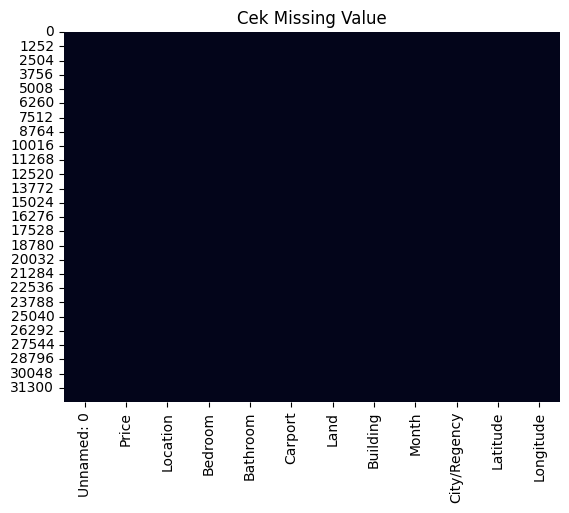

In [410]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Cek Missing Value')

tidak ada missing value

In [411]:
print(df.duplicated().sum())

0


tidak ada data duplikat

In [412]:
df.nunique()

Unnamed: 0      32536
Price             844
Location           66
Bedroom             8
Bathroom            7
Carport             4
Land              520
Building          416
Month               3
City/Regency        3
Latitude           66
Longitude          66
dtype: int64

- city = one hot encoding, 
- location = target encoding (diisi rata-rata harga rumah daerah tsb), 
- latitide dan longitude drop karena sudah direpresentasikan oleh kolom location

In [413]:
df = df.drop(columns=['Unnamed: 0','Latitude', 'Longitude'])

In [414]:
df.head()

,Price,Location,Bedroom,Bathroom,Carport,Land,Building,Month,City/Regency
0,1600000000.0000,Padalarang,2,1,1,72,50,8,West Bandung Regency
1,850000000.0000,Parongpong,2,1,1,70,80,8,West Bandung Regency
2,875000000.0000,Buah Batu,3,2,1,60,70,8,Bandung City
3,1750000000.0000,Bojongsoang,2,3,1,90,94,8,Bandung Regency
4,4900000000.0000,Bojongloa Kidul,4,4,0,200,300,8,Bandung City


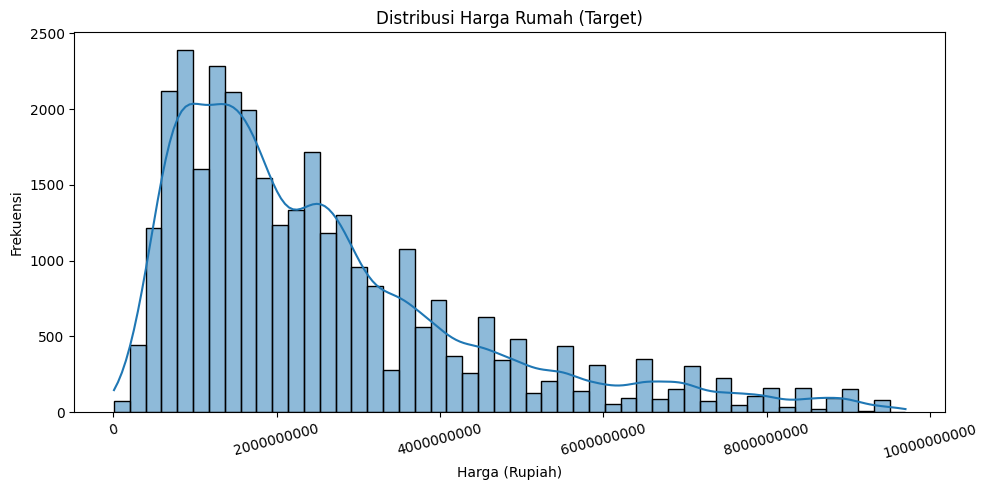

In [415]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], kde=True, bins=50)
plt.title('Distribusi Harga Rumah (Target)')
plt.xlabel('Harga (Rupiah)')
plt.ylabel('Frekuensi')
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

kolom target right skewed, antisipasi dengan log1p for preprocessing

3. Exploratory Data Analysis (EDA)

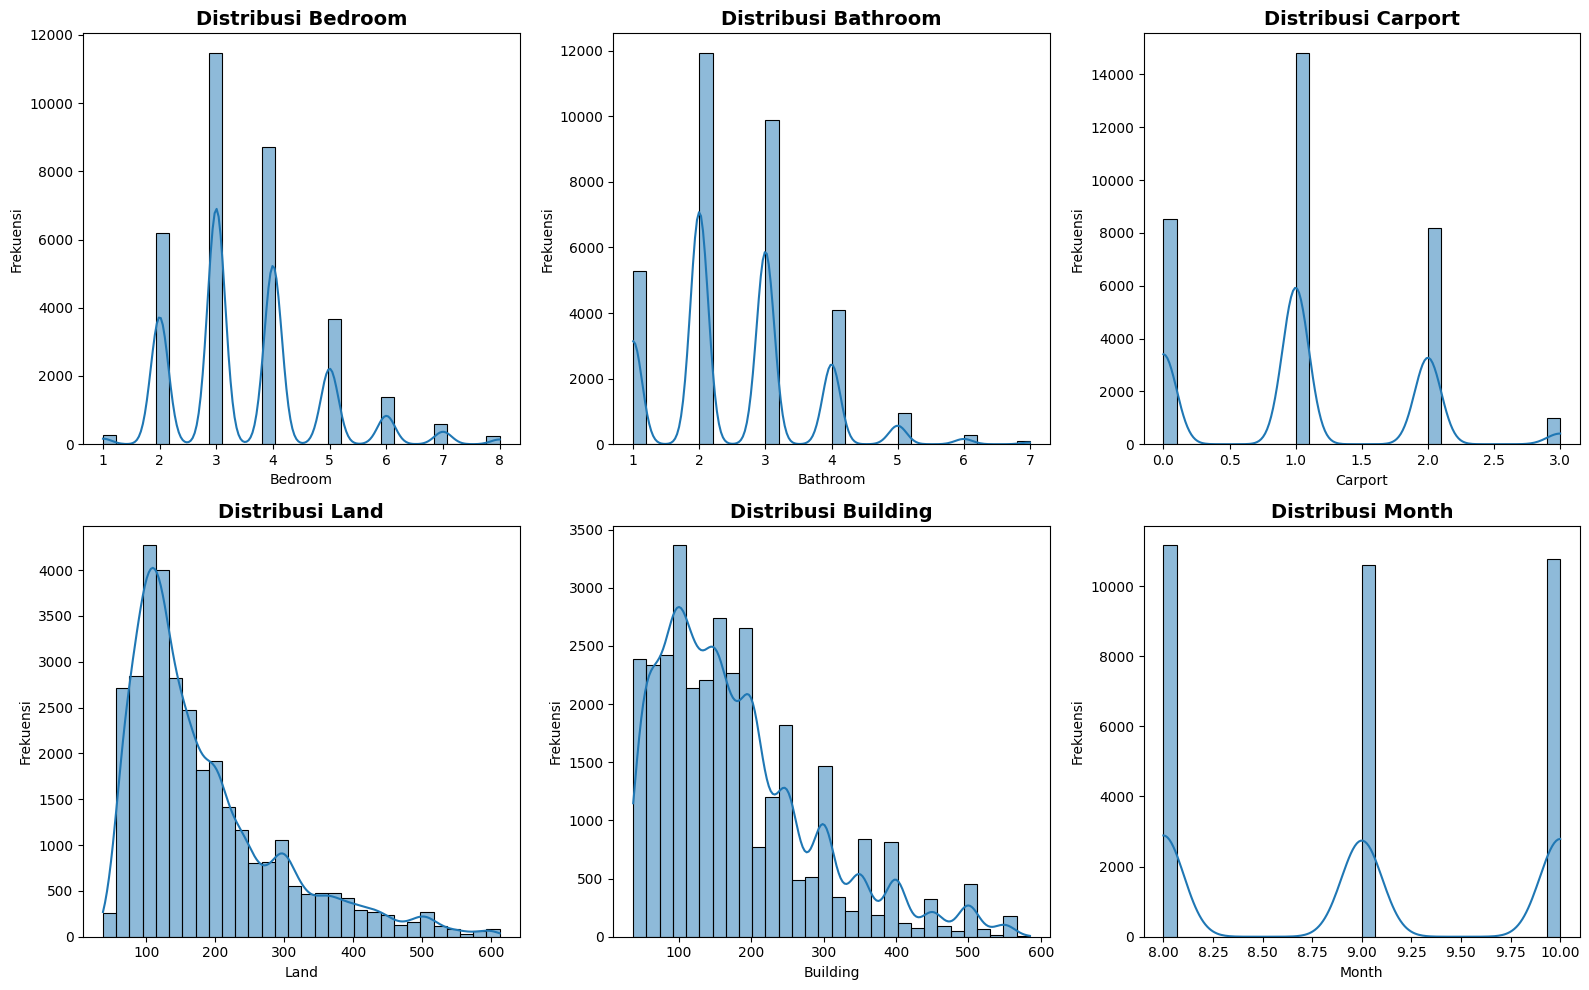

In [416]:
# cek distribusi kolom numerik
kolom_numerik = ['Bedroom', 'Bathroom', 'Carport', 'Land', 'Building', 'Month']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

right skewed for building & land, antisipasi dengan log1p dan standard scaler untuk meminimalisir rentang

In [417]:
#cek outlier pada kolom land dan building
cek_kolom_outlier = ['Land', 'Building']
outlier_report = {}

for col in cek_kolom_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = (df[col] < lower) | (df[col] > upper)
    outlier_report[col] = outliers.sum()
    print(f"{col}: {outliers.sum()} outlier ({outliers.mean()*100:.2f}%)")

Land: 1729 outlier (5.31%)
Building: 1174 outlier (3.61%)


ignore outliers, bcs it make sense, memang ada rumah yang memiliki lahan yang luas dan ukuran bangunan yang luas

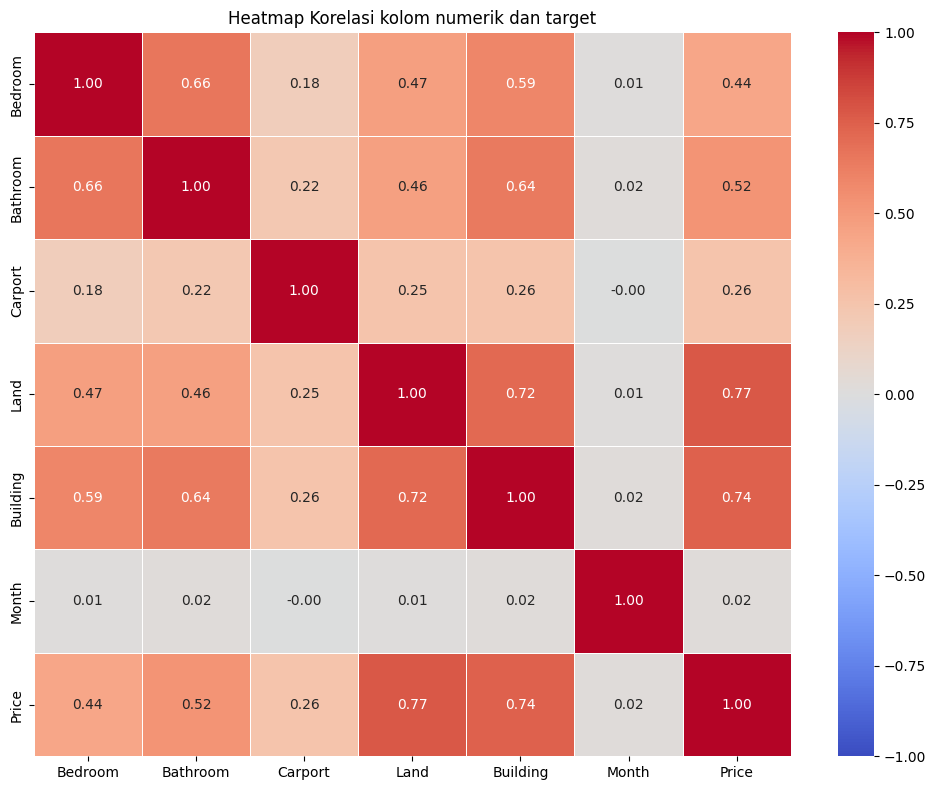

In [418]:
# cek korelasi kolom numerik dan target
kolom_numerik_dan_target = ['Bedroom', 'Bathroom', 'Carport', 'Land', 'Building', 'Month', 'Price']
corr_matrix = df[kolom_numerik_dan_target].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Heatmap Korelasi kolom numerik dan target')
plt.tight_layout()
plt.show()

drop kolom month karena sedikit memiliki pengaruh dengan target maupun fitur lainnya

In [419]:
# cek multikolinearitas kolom numerik
x = df[kolom_numerik]
x_with_const = add_constant(x)

vif_df = pd.DataFrame()
vif_df['Fitur'] = x_with_const.columns
vif_df['VIF'] = [variance_inflation_factor(x_with_const.values, i) for i in range(len(x_with_const.columns))]

vif_df = vif_df[vif_df["Fitur"] != "const"].sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_df)

      Fitur    VIF
0  Building 2.8457
1  Bathroom 2.1660
2      Land 2.0956
3   Bedroom 1.9397
4   Carport 1.0876
5     Month 1.0004


tidak terjadi multikolinearitas pada kolom-kolom numerik tersebut

In [420]:
# cek apakah kolom kategorikal berpengaruh dengan target
target = 'Price'

categorical_cols = [
    'Location',
    'City/Regency'
]
for col in categorical_cols:
    kategori_groups = [group[target].dropna() for _, group in df.groupby(col)]
    f_stat, p_val = stats.f_oneway(*kategori_groups)
    print(f_stat)
    print(p_val)

234.2626280653126
0.0
1281.9955808095938
0.0


these two feature categorical is relevant for the target

4. Data Preprocessing

In [421]:
# split dataset untuk data train dan test, data test mengambil 20 %
X = df.drop(columns=['Price', 'Month'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 


5. Feature Engineering

In [422]:
# transformasi kolom target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [423]:
# buat feature engineering
def engineer_features(df):
    X = df.copy()
    X["Bath_per_Bed_Ratio"] = X["Bathroom"] / (X["Bedroom"] + 1e-6)
    X["Building_per_Bedroom"] = X["Building"] / (X["Bedroom"] + 1e-6)
    X["Land_Sisa"] = np.maximum(0, X["Land"] - X["Building"])
    X["Building_Coverage_Ratio"] = (X["Building"] / (X["Land"] + 1e-6)).clip(upper=3)
    X["Total_Facility"] = X["Bedroom"] + X["Bathroom"] + X["Carport"]
    return X

feature_engineer_step = FunctionTransformer(engineer_features)

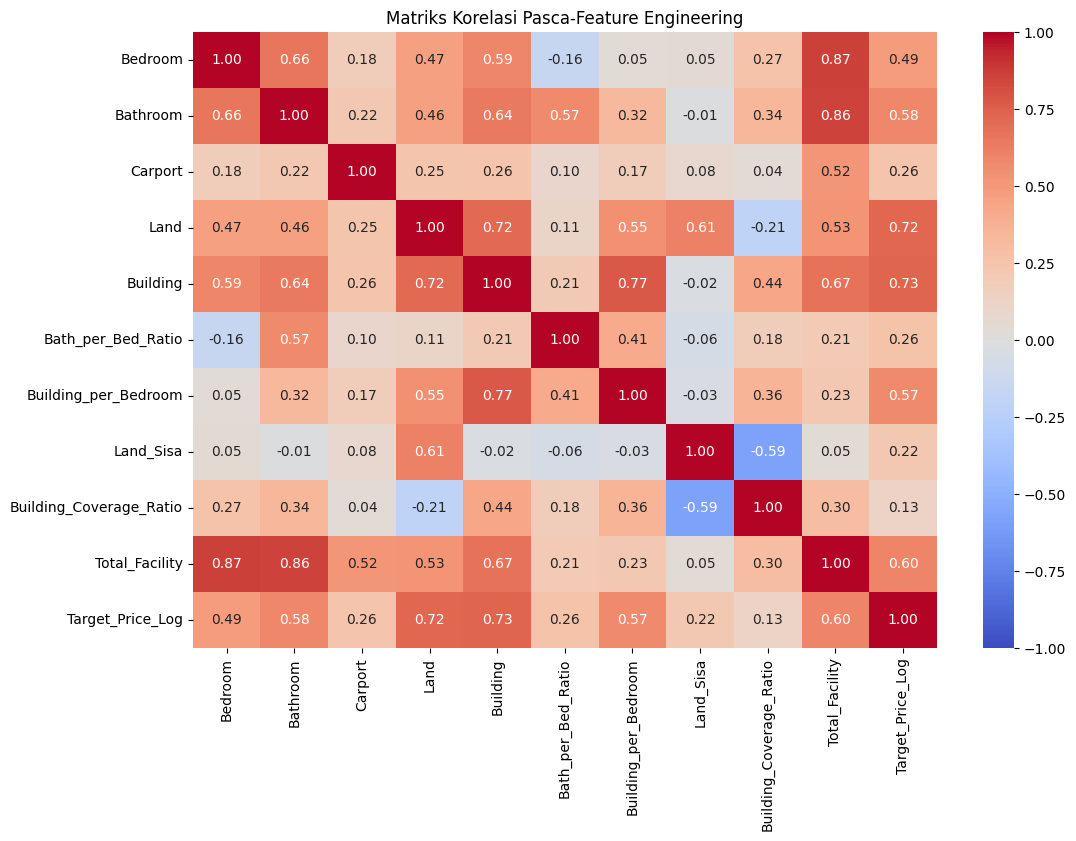

In [424]:
# fit feature engineering dan cek korelasi
X_train_fe = engineer_features(X_train)

train_check = X_train_fe.copy()
train_check['Target_Price_Log'] = y_train_log

corr_matrix = train_check.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriks Korelasi Pasca-Feature Engineering')
plt.show()

semua kolom fitur tersebut memiliki dampak terhadap kolom target

In [425]:
# cek multikolinearitas after fe
x = X_train_fe[['Bedroom', 'Bathroom', 'Carport', 'Land', 'Building', 'Bath_per_Bed_Ratio', 'Building_per_Bedroom', 'Land_Sisa', 'Building_Coverage_Ratio', 'Total_Facility']]
x_with_const = add_constant(x)

vif_df = pd.DataFrame()
vif_df['Fitur'] = x_with_const.columns
vif_df['VIF'] = [variance_inflation_factor(x_with_const.values, i) for i in range(len(x_with_const.columns))]

vif_df = vif_df[vif_df["Fitur"] != "const"].sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_df)

                     Fitur     VIF
0                  Bedroom     inf
1                 Bathroom     inf
2                  Carport     inf
3           Total_Facility     inf
4                     Land 27.4883
5                 Building 25.7010
6     Building_per_Bedroom  9.3542
7       Bath_per_Bed_Ratio  8.1709
8                Land_Sisa  6.5399
9  Building_Coverage_Ratio  5.6282


In [426]:
x.head()

,Bedroom,Bathroom,Carport,Land,Building,Bath_per_Bed_Ratio,Building_per_Bedroom,Land_Sisa,Building_Coverage_Ratio,Total_Facility
32215,5,2,0,101,160,0.4000,32.0000,0,1.5842,7
31639,2,2,0,120,90,1.0000,45.0000,30,0.7500,4
5455,3,2,0,126,147,0.6667,49.0000,0,1.1667,5
19690,4,3,2,512,405,0.7500,101.2500,107,0.7910,9
25902,4,4,2,146,252,1.0000,63.0000,0,1.7260,10


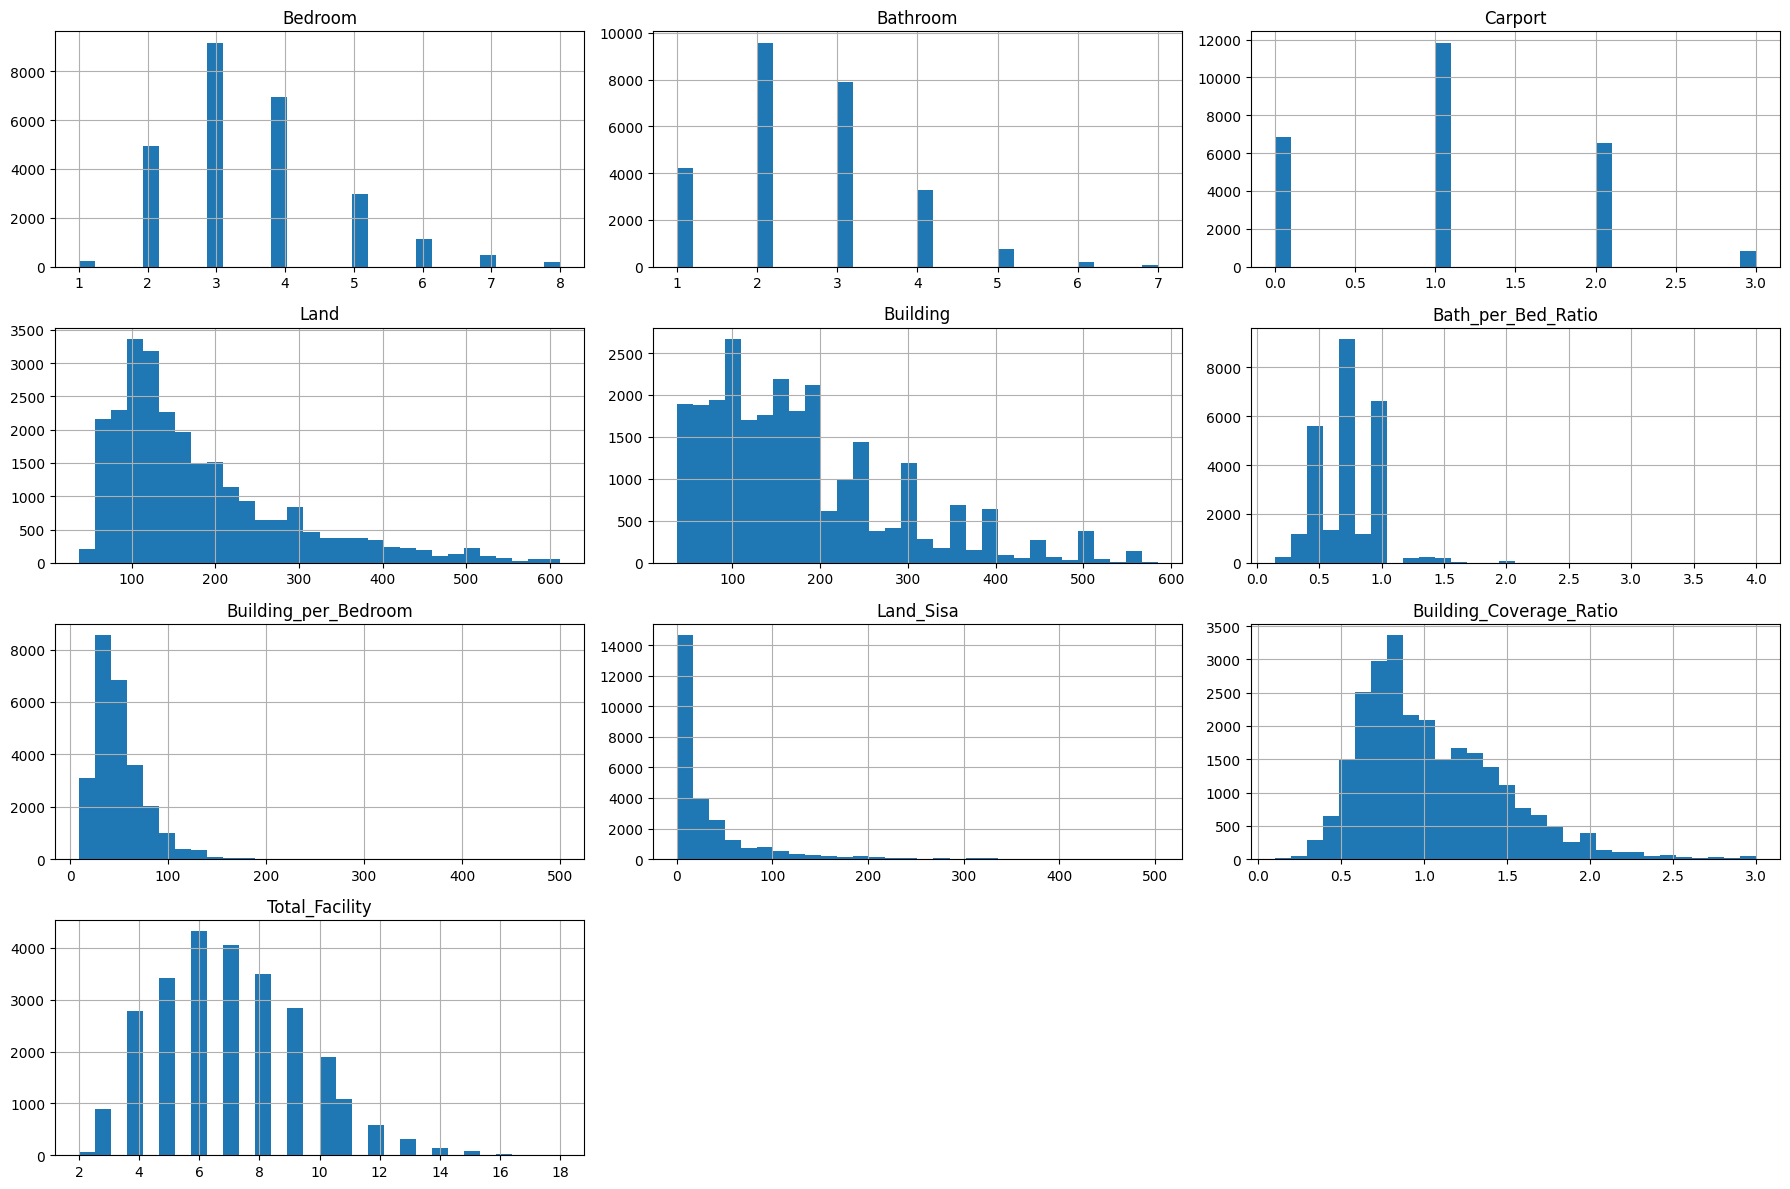

In [427]:
num_cols = x.select_dtypes(include="number").columns

x[num_cols].hist(figsize=(18,12), bins=30)
plt.tight_layout()
plt.show()

ada indikasi multikolinearitas, kita harus cek terlebih dahulu dengan rmse

In [428]:
# buat pipeline untuk transformasi
log_scale_pipe = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ('scale', StandardScaler()),
])
 
target_scale_pipe = Pipeline([
    ('target_enc', TargetEncoder(smooth="auto", cv=5)),
    ('scale', StandardScaler()),
])

# terdapat 2 pipeline untuk membandingkan model yang sensitif terhadap multikolinearitas dan tidak 
preprocessor_with_fe = ColumnTransformer(
    transformers=[
        ('log_scale', log_scale_pipe, ['Land', 'Building', 'Land_Sisa', 'Building_per_Bedroom']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['City/Regency']),
        ('scale', StandardScaler(), ['Bedroom', 'Bathroom', 'Carport', 'Bath_per_Bed_Ratio'
                                     ,'Total_Facility'
                                     ,'Building_Coverage_Ratio'
                                     ]),
        ('target_scale', target_scale_pipe, ['Location']),
    ],
    remainder='passthrough'
)

preprocessor_without_fe = ColumnTransformer(
    transformers=[
        ('log_scale', log_scale_pipe, ['Land', 'Building']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['City/Regency']),
        ('scale', StandardScaler(), ['Bedroom', 'Bathroom', 'Carport']),
        ('target_scale', target_scale_pipe, ['Location']),
    ],
    remainder='passthrough'
)

In [429]:
# gabung fe dengan pipeline
def build_pipeline_without_fe(model):
    return Pipeline([
        ("preprocessor", preprocessor_without_fe),
        ("model", model),
    ])

def build_pipeline_with_fe(model):
    return Pipeline([
        ("feature_engineering", feature_engineer_step),
        ("preprocessor", preprocessor_with_fe),
        ("model", model),
    ])

6. Modeling

In [430]:
# model yang digunakan
models = {
    "Baseline (Mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective="reg:absoluteerror", eval_metric="mae", random_state=42),
    "LightGBM": LGBMRegressor(objective="regression_l1", metric="mae", random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(loss_function="MAE", eval_metric="MAE", random_seed=42, verbose=0)
}

In [431]:
# fungsi untuk parameter model
def benchmark_models(models, pipeline_builder, X, y, cv, scoring):
    results = []
    for name, model in models.items():
        start = time.time()
        pipe = pipeline_builder(model)
        cv_results = cross_validate(
            pipe, X, y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
        )

        elapsed = time.time() - start
        results.append({
            "Model": name,
            "RMSE (log)": -cv_results["test_RMSE"].mean(),
            "RMSE std": cv_results["test_RMSE"].std(),
            "MAE (log)": -cv_results["test_MAE"].mean(),
            "R2": cv_results["test_R2"].mean(),
            "Time (s)": elapsed,
        })
        print(f"{name:<25} selesai ({elapsed:.1f}s)")

    return (
        pd.DataFrame(results)
        .sort_values("RMSE (log)")
        .reset_index(drop=True)
    )

In [432]:
# evaluasi menggunakan kfold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

pd.options.display.float_format = "{:.4f}".format

In [433]:
# models without fe
baseline_results = benchmark_models(
    models=models,
    pipeline_builder=build_pipeline_without_fe,
    X=X_train,
    y=y_train_log,
    cv=cv,
    scoring=scoring,
)

baseline_results

Baseline (Mean)           selesai (0.1s)
Linear Regression         selesai (0.1s)
Ridge Regression          selesai (0.1s)
Lasso Regression          selesai (0.1s)
ElasticNet                selesai (0.1s)
KNN Regressor             selesai (0.4s)
Decision Tree             selesai (0.3s)
Random Forest             selesai (4.5s)
Extra Trees               selesai (3.3s)
Gradient Boosting         selesai (2.7s)
HistGradientBoosting      selesai (0.8s)
XGBoost                   selesai (1.3s)
LightGBM                  selesai (0.9s)
CatBoost                  selesai (8.6s)


,Model,RMSE (log),RMSE std,MAE (log),R2,Time (s)
0,Extra Trees,0.2768,0.0146,0.1593,0.8642,3.3092
1,Random Forest,0.2821,0.0126,0.1713,0.8590,4.5493
2,XGBoost,0.3139,0.0157,0.2121,0.8254,1.2895
3,HistGradientBoosting,0.3194,0.0142,0.2279,0.8192,0.7975
4,LightGBM,0.3233,0.0146,0.2231,0.8149,0.9015
5,CatBoost,0.3234,0.0154,0.2244,0.8147,8.6277
6,Gradient Boosting,0.3389,0.0142,0.2468,0.7965,2.7381
7,KNN Regressor,0.3426,0.0118,0.2389,0.7921,0.3789
8,Ridge Regression,0.3584,0.0137,0.2646,0.7725,0.1442
9,Linear Regression,0.3584,0.0137,0.2646,0.7725,0.1409


In [434]:
# models with fe
fe_results = benchmark_models(
    models=models,
    pipeline_builder=build_pipeline_with_fe,
    X=X_train,
    y=y_train_log,
    cv=cv,
    scoring=scoring,
)

fe_results

Baseline (Mean)           selesai (0.2s)
Linear Regression         selesai (0.2s)
Ridge Regression          selesai (0.2s)
Lasso Regression          selesai (0.2s)
ElasticNet                selesai (0.2s)
KNN Regressor             selesai (0.6s)
Decision Tree             selesai (0.4s)
Random Forest             selesai (7.1s)
Extra Trees               selesai (4.1s)
Gradient Boosting         selesai (4.9s)
HistGradientBoosting      selesai (0.9s)
XGBoost                   selesai (1.4s)
LightGBM                  selesai (1.0s)
CatBoost                  selesai (8.6s)


,Model,RMSE (log),RMSE std,MAE (log),R2,Time (s)
0,Random Forest,0.2784,0.0161,0.1689,0.8625,7.0804
1,Extra Trees,0.2791,0.0141,0.1576,0.8620,4.1278
2,XGBoost,0.3148,0.0168,0.2114,0.8244,1.4051
3,HistGradientBoosting,0.3171,0.0141,0.2259,0.8219,0.8987
4,CatBoost,0.3215,0.0158,0.2226,0.8168,8.6299
5,LightGBM,0.3228,0.0162,0.2220,0.8154,1.0150
6,Gradient Boosting,0.3369,0.0152,0.2451,0.7989,4.8946
7,KNN Regressor,0.3470,0.0113,0.2431,0.7867,0.6252
8,Linear Regression,0.3562,0.0140,0.2634,0.7753,0.1610
9,Ridge Regression,0.3562,0.0140,0.2634,0.7753,0.1625


In [435]:
# cek perbandingan dengan dan tanpa fe
comparison = (
    baseline_results
    .merge(
        fe_results,
        on="Model",
        suffixes=("_Without_FE", "_With_FE"),
    )
)

comparison["Improvement"] = (
    comparison["RMSE (log)_Without_FE"]
    -
    comparison["RMSE (log)_With_FE"]
)

comparison = comparison.sort_values(
    "RMSE (log)_With_FE",
    ascending=True,
)

comparison

,Model,RMSE (log)_Without_FE,RMSE std_Without_FE,MAE (log)_Without_FE,R2_Without_FE,Time (s)_Without_FE,RMSE (log)_With_FE,RMSE std_With_FE,MAE (log)_With_FE,R2_With_FE,Time (s)_With_FE,Improvement
1,Random Forest,0.2821,0.0126,0.1713,0.8590,4.5493,0.2784,0.0161,0.1689,0.8625,7.0804,0.0037
0,Extra Trees,0.2768,0.0146,0.1593,0.8642,3.3092,0.2791,0.0141,0.1576,0.8620,4.1278,-0.0023
2,XGBoost,0.3139,0.0157,0.2121,0.8254,1.2895,0.3148,0.0168,0.2114,0.8244,1.4051,-0.0009
3,HistGradientBoosting,0.3194,0.0142,0.2279,0.8192,0.7975,0.3171,0.0141,0.2259,0.8219,0.8987,0.0024
5,CatBoost,0.3234,0.0154,0.2244,0.8147,8.6277,0.3215,0.0158,0.2226,0.8168,8.6299,0.0018
4,LightGBM,0.3233,0.0146,0.2231,0.8149,0.9015,0.3228,0.0162,0.2220,0.8154,1.0150,0.0005
6,Gradient Boosting,0.3389,0.0142,0.2468,0.7965,2.7381,0.3369,0.0152,0.2451,0.7989,4.8946,0.0020
7,KNN Regressor,0.3426,0.0118,0.2389,0.7921,0.3789,0.3470,0.0113,0.2431,0.7867,0.6252,-0.0044
9,Linear Regression,0.3584,0.0137,0.2646,0.7725,0.1409,0.3562,0.0140,0.2634,0.7753,0.1610,0.0022
8,Ridge Regression,0.3584,0.0137,0.2646,0.7725,0.1442,0.3562,0.0140,0.2634,0.7753,0.1625,0.0022


kesimpulannya lebih banyak hasil improvement yang positif dengan menggunakan fe, jadi fe malah membantu model meskipun terindikasi adanya multikolinearitas

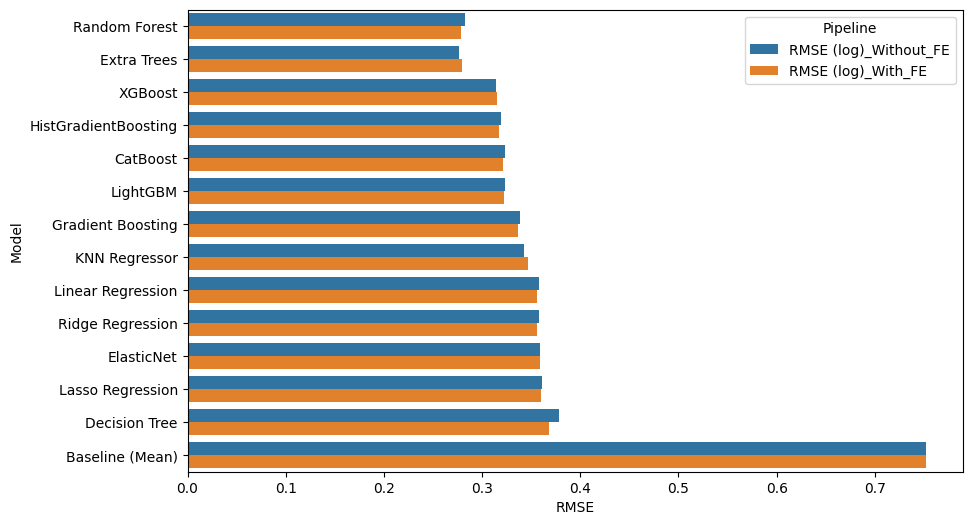

In [436]:
# visualisasi perbandingan model with fe and without fe
comparison_plot = comparison.melt(
    id_vars="Model",
    value_vars=[
        "RMSE (log)_Without_FE",
        "RMSE (log)_With_FE",
    ],
    var_name="Pipeline",
    value_name="RMSE"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=comparison_plot,
    x="RMSE",
    y="Model",
    hue="Pipeline"
)
plt.show()

Berdasarkan hasil perbandingan, penerapan Feature Engineering tidak memberikan peningkatan performa yang konsisten pada seluruh model regresi. Beberapa model seperti Random Forest dan Linear Regression mengalami sedikit penurunan nilai RMSE, sedangkan model terbaik, yaitu Extra Trees Regressor, justru memperoleh RMSE terendah (0,2760) tanpa Feature Engineering


In [437]:
# mengambil pipeline terbaik
best_pipeline_map = {}

for _, row in comparison.iterrows():
    model_name = row["Model"]
    if row["RMSE (log)_With_FE"] < row["RMSE (log)_Without_FE"]:
        best_pipeline_map[model_name] = build_pipeline_with_fe
    else:
        best_pipeline_map[model_name] = build_pipeline_without_fe

In [438]:
# mengambil 5 model terbaik
comparison["Best RMSE"] = comparison[
["RMSE (log)_Without_FE",
"RMSE (log)_With_FE"
]].min(axis=1)

top_models = (
    comparison
    .sort_values("Best RMSE")
    .head(5)["Model"]
    .tolist()
)

top_models

['Extra Trees', 'Random Forest', 'XGBoost', 'HistGradientBoosting', 'CatBoost']

In [439]:
# membandingkan 5 model terbaik tersebut dengan model evaluasi asli
original_scale_results = []
for name in top_models:
    builder = best_pipeline_map[name]
    pipe = builder(models[name])
    y_pred_log = cross_val_predict(
        pipe,
        X_train,
        y_train_log,
        cv=cv,
        n_jobs=-1,
    )

    y_true = np.expm1(y_train_log)
    y_pred = np.expm1(y_pred_log)

    original_scale_results.append({
        "Model": name,
        "RMSE (Rupiah)": root_mean_squared_error(
            y_true,
            y_pred,
        ),
        "MAE (Rupiah)": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "MAPE (%)":
        mean_absolute_percentage_error(
            y_true,
            y_pred,
        ) * 100,

        "R²":
        r2_score(
            y_true,
            y_pred,
        ),
    })

original_scale_df = (
    pd.DataFrame(original_scale_results)
    .sort_values("RMSE (Rupiah)")
    .reset_index(drop=True)
)

original_scale_df.style.format({
    "RMSE (Rupiah)": "Rp {:,.0f}",
    "MAE (Rupiah)": "Rp {:,.0f}",
    "Median AE (Rupiah)": "Rp {:,.0f}",
    "MAPE (%)": "{:.2f}%",
    "R²": "{:.4f}",
})

original_scale_df

,Model,RMSE (Rupiah),MAE (Rupiah),MAPE (%),R²
0,Extra Trees,670024525.1410,358561472.8975,24.2145,0.8741
1,Random Forest,677254429.8804,381652878.5072,25.0247,0.8714
2,XGBoost,799936879.2977,496543999.7400,30.6315,0.8206
3,HistGradientBoosting,827256476.1700,535881477.2547,30.6330,0.8081
4,CatBoost,829276409.8089,526559386.0176,31.4477,0.8072


In [440]:
# mengambil 1 model terbaik
comparison["Best RMSE"] = comparison[
["RMSE (log)_Without_FE",
"RMSE (log)_With_FE",]].min(axis=1)

best_model_name = comparison.sort_values(
    "Best RMSE"
).iloc[0]["Model"]

best_model_name

'Extra Trees'

In [441]:
# mengambil 1 pipeline terbaik dari model terbaik
best_pipeline_builder = best_pipeline_map[
    best_model_name
]

best_pipeline_builder

<function __main__.build_pipeline_without_fe(model)>

In [442]:
# membuat pipeline dengan best model
best_model = models[
    best_model_name
]

final_pipeline = best_pipeline_builder(
    best_model
)

In [443]:
# latih model dengan data train
final_pipeline.fit(
    X_train,
    y_train_log,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log_scale', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [444]:
# prefict data train
y_pred_log = final_pipeline.predict(
    X_test
)

y_pred = np.expm1(
    y_pred_log
)

y_true = np.expm1(
    y_test_log
)

In [445]:
# evaluasi hasil predict
final_results = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "MAPE",
        "R²",
    ],
    "Value": [
        root_mean_squared_error(
            y_true,
            y_pred,
        ),
        mean_absolute_error(
            y_true,
            y_pred,
        ),
        mean_absolute_percentage_error(
            y_true,
            y_pred,
        ) * 100,
        r2_score(
            y_true,
            y_pred,
        ),
    ],
})

final_results

,Metric,Value
0,RMSE,626989127.8415
1,MAE,326176422.1456
2,MAPE,18.3516
3,R²,0.8845


7. Hyperparameter Tuning

In [446]:
# buat pipeline dan parameter untuk tuning
pipe = build_pipeline_without_fe(
    ExtraTreesRegressor(random_state=42)
)

param_dist = {
    "model__n_estimators": [200,300,500],
    "model__max_depth": [None, 10,20,30],
    "model__min_samples_split": [2,5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__max_features": ["sqrt","log2",None]
}

In [447]:
# tuning menggunakan RSCV
random_search = RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train_log
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [448]:
# cek hasil tuning
tuning_results = pd.DataFrame(
    random_search.cv_results_
)

tuning_results = tuning_results.sort_values(
    "rank_test_score"
)

tuning_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
15,15.1887,0.0299,1.2359,0.0569,500,5,1,None,30,"{'model__n_estimators': 500, 'model__min_sampl...",-0.2731,-0.2829,-0.2537,-0.2636,-0.2961,-0.2739,0.0148,1
6,5.1450,1.3335,3.6538,0.9182,200,5,1,None,20,"{'model__n_estimators': 200, 'model__min_sampl...",-0.2741,-0.2848,-0.2554,-0.2657,-0.2976,-0.2755,0.0147,2
28,6.5862,0.5799,3.5072,0.4534,200,2,2,None,None,"{'model__n_estimators': 200, 'model__min_sampl...",-0.2751,-0.2848,-0.2587,-0.2667,-0.2983,-0.2767,0.0138,3
12,11.6084,0.3128,2.1947,0.6772,300,2,2,None,20,"{'model__n_estimators': 300, 'model__min_sampl...",-0.2769,-0.2863,-0.2585,-0.2714,-0.3002,-0.2787,0.0140,4
20,11.3621,1.3060,4.4715,0.1915,300,10,2,None,30,"{'model__n_estimators': 300, 'model__min_sampl...",-0.2811,-0.2907,-0.2655,-0.2740,-0.3066,-0.2836,0.0142,5


In [449]:
print(random_search.best_score_)
print(random_search.best_params_)

-0.27388300975195656
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 30}


In [450]:
# simpan hasil tuning terbaik
best_pipeline = random_search.best_estimator_

8. Train Final Model

In [451]:
# latih data train menggunakan model terbaik dan hasil tuning
final_model = random_search.best_estimator_

final_model.fit(
    X_train,
    y_train_log
)

y_pred_log = final_model.predict(
    X_test
)

y_test_original = np.expm1(
    y_test_log
)

y_pred_original = np.expm1(
    y_pred_log
)

In [452]:
# evaluasi model
final_metrics = pd.DataFrame({
    "Metric":[
        "RMSE",
        "MAE",
        "MAPE",
        "R²"
    ],
    "Value":[
        root_mean_squared_error(
            y_test_original,
            y_pred_original
        ),
        mean_absolute_error(
            y_test_original,
            y_pred_original
        ),
        mean_absolute_percentage_error(
            y_test_original,
            y_pred_original
        )*100,
        r2_score(
            y_test_original,
            y_pred_original
        )
    ]
})

final_metrics

,Metric,Value
0,RMSE,635404834.9733
1,MAE,349456996.6388
2,MAPE,19.1123
3,R²,0.8814


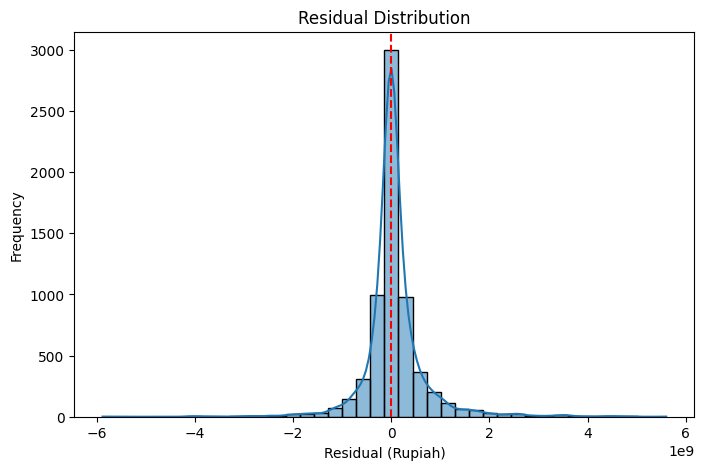

In [453]:
# cek akurasi dengan residual
residual = y_test_original - y_pred_original

plt.figure(figsize=(8,5))

sns.histplot(
    residual,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Distribution")
plt.xlabel("Residual (Rupiah)")
plt.ylabel("Frequency")

plt.show()

Berdasarkan distribusi residual, sebagian besar residual terpusat di sekitar nilai 0, yang menunjukkan bahwa model tidak memiliki bias sistematis yang signifikan dalam melakukan prediksi.

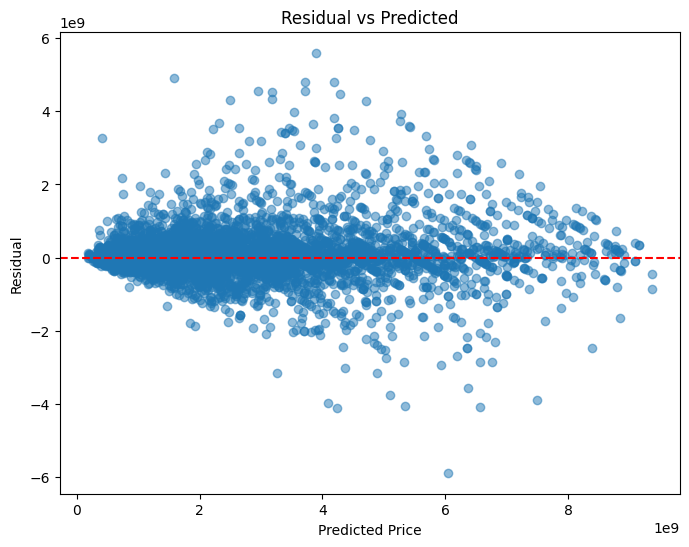

In [454]:
# perbandingan error residual dan harga predicted
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_original,
    residual,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual vs Predicted")

plt.show()

residual tersebar di sekitar nol artinya model sudah dapat memprediksi dengan baik dan tidak memiliki bias yang kuat

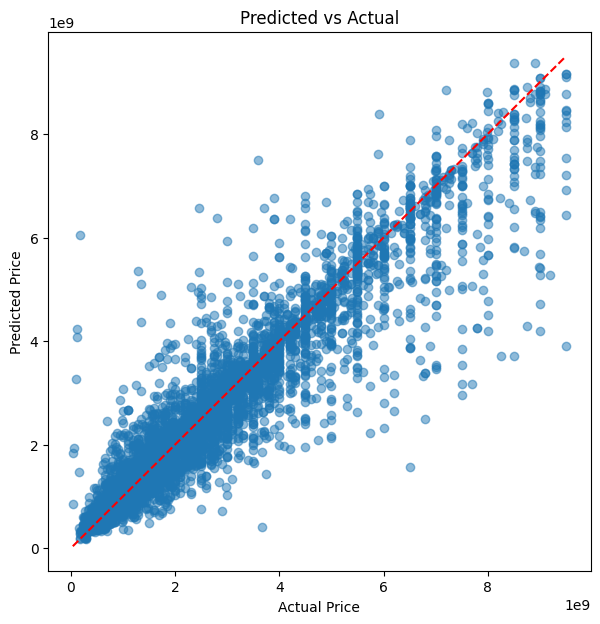

In [455]:
# harga predicted vs harga aktual
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_original,
    y_pred_original,
    alpha=0.5
)

plt.plot(
    [
        y_test_original.min(),
        y_test_original.max()
    ],
    [
        y_test_original.min(),
        y_test_original.max()
    ],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")

plt.show()

Grafik Predicted vs Actual menunjukkan adanya korelasi linear yang kuat antara harga aktual dan harga hasil prediksi, di mana titik-titik data berkumpul rapat mengikuti garis acuan diagonal merah. Hal ini mengindikasikan bahwa secara umum model mampu memprediksi nilai harga dengan tingkat akurasi yang baik, khususnya pada rentang harga rendah hingga menengah.

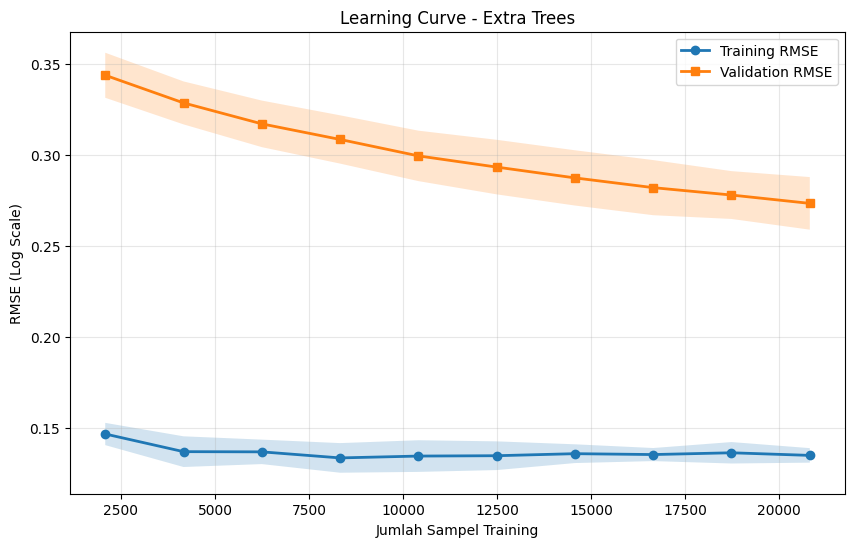

In [456]:
# cek learning curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=final_model,
    X=X_train,
    y=y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

train_rmse = -train_scores
valid_rmse = -valid_scores

train_mean = train_rmse.mean(axis=1)
train_std = train_rmse.std(axis=1)

valid_mean = valid_rmse.mean(axis=1)
valid_std = valid_rmse.std(axis=1)
 
plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label="Training RMSE"
)

plt.plot(
    train_sizes,
    valid_mean,
    marker='s',
    linewidth=2,
    label="Validation RMSE"
)

plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    valid_mean-valid_std,
    valid_mean+valid_std,
    alpha=0.2
)

plt.xlabel("Jumlah Sampel Training")
plt.ylabel("RMSE (Log Scale)")
plt.title(f"Learning Curve - {best_model_name}")
plt.grid(alpha=0.3)
plt.legend()

plt.show()


Grafik Learning Curve menunjukkan bahwa nilai Training RMSE relatif rendah dan stabil seiring bertambahnya jumlah data pelatihan, sedangkan Validation RMSE terus menurun. Hal ini menunjukkan bahwa penambahan data memberikan peningkatan kemampuan generalisasi model. 

9. Feature Important

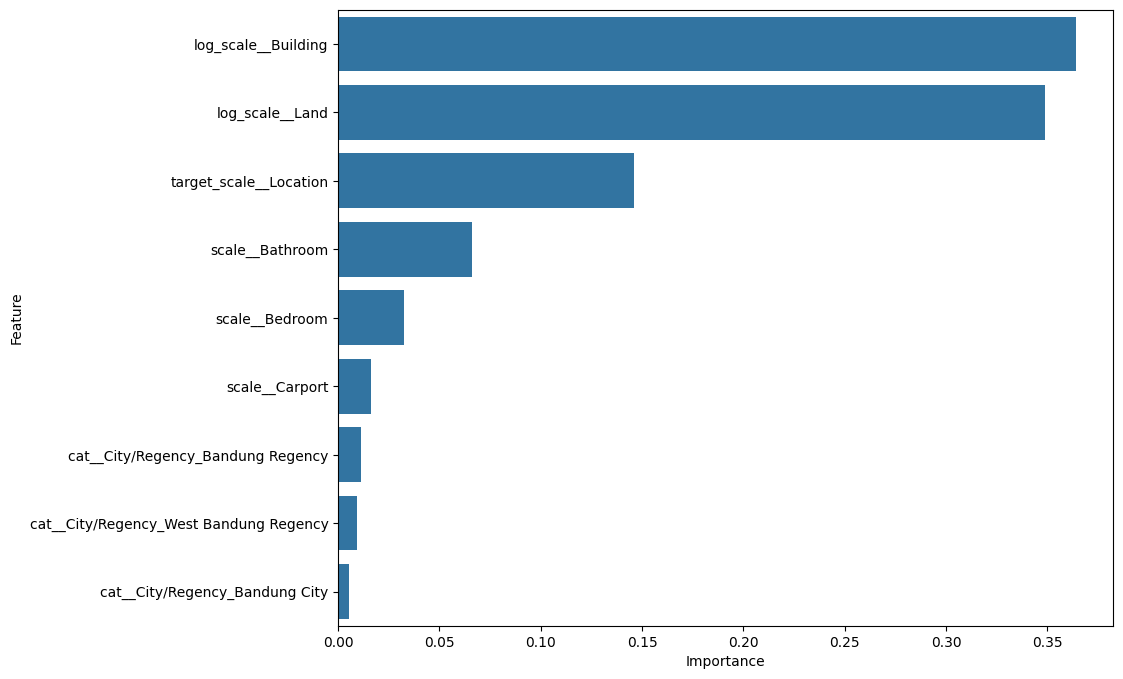

In [457]:
# cek feature important
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = final_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.show()

fitur yang paling penting masih didominasi dengan fitur asli yaitu luas tanah dan luas bangunan

In [458]:
# simpan model
joblib.dump(
    best_model,
    "../models/house_price_pipeline.pkl", 
    compress=3
)

['../models/house_price_pipeline.pkl']

10. Kesimpulan

Proyek ini bertujuan membangun model regresi untuk memprediksi harga rumah di wilayah Bandung Raya (Kota Bandung, Kabupaten Bandung, dan Kabupaten Bandung Barat) berdasarkan karakteristik properti seperti jumlah kamar tidur, kamar mandi, carport, luas tanah, luas bangunan, dan lokasi. Dataset yang digunakan berisi 32.536 data tanpa nilai kosong maupun duplikat, dengan distribusi harga yang right-skewed sehingga target ditransformasi menggunakan log1p sebelum pemodelan. Hasil EDA menunjukkan bahwa lokasi (Location dan City/Regency) memiliki pengaruh signifikan terhadap harga (ANOVA, p < 0.05), sementara variabel numerik seperti luas bangunan dan luas tanah tidak menunjukkan multikolinearitas berarti pada bentuk mentahnya (VIF < 3).

Empat belas model dibandingkan menggunakan 5-fold cross-validation, mencakup baseline (DummyRegressor), model linear (Linear Regression, Ridge, Lasso, ElasticNet), serta model berbasis pohon dan ensemble (Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, CatBoost, dan lainnya). Sebagai bagian dari eksperimen, dilakukan pengujian ablasi terhadap fitur turunan (Building_per_Bedroom, Bath_per_Bed_Ratio, dll) untuk menguji apakah feature engineering benar-benar meningkatkan performa — hasilnya menunjukkan peningkatan yang tidak konsisten dan cenderung marginal di sebagian besar model, bahkan memperkenalkan multikolinearitas tambahan (VIF hingga 17,6 pada fitur Building). Berdasarkan temuan ini, model final dipilih untuk tetap menggunakan fitur asli tanpa rekayasa rasio tambahan, dengan Random Forest terpilih sebagai model dengan performa terbaik pada skala log (RMSE ≈ 0,279).

Setelah melalui hyperparameter tuning menggunakan RandomizedSearchCV dan evaluasi akhir pada test set yang belum pernah dilihat model selama proses pemilihan maupun tuning, model mencapai RMSE sebesar Rp 635 juta, MAE sebesar Rp 348,6 juta, MAPE sebesar 19,08%, dan R² sebesar 0,881 — artinya model mampu menjelaskan sekitar 88,04% variasi harga rumah di dataset ini. Selisih yang tipis antara skor cross-validation dan skor test set mengindikasikan model cukup general dan tidak overfitting terhadap data latih. Meski begitu, MAPE sebesar ~19% menunjukkan model masih memiliki ruang perbaikan, terutama untuk properti dengan harga ekstrem tinggi yang jumlahnya relatif sedikit di dataset. Ke depannya, performa model berpotensi ditingkatkan dengan menambahkan fitur eksternal seperti jarak ke fasilitas umum, kondisi bangunan, atau tahun pembangunan, yang tidak tersedia pada dataset saat ini.
